# Workflow Pattern: Reflection

The Reflection Pattern is where an AI agent **iteratively** evaluates and improves its own outputs through self-assessment and feedback loops, similar to reflective agents that we covered in **langgrapg/2.reflection-agents.ipynb**. Rather than providing a single recommendation, the system creates an initial proposal, critically evaluates it against established criteria, and then refines the output based on that evaluation. This cycle continues **until the system achieves an optimal solution** that meets predefined quality standards.

In this section, we'll build an intelligent investment advisory system that iteratively refines portfolio recommendations through continuous evaluation and feedback loops. The system combines aggressive growth strategies with conservative risk assessment to find the optimal balance for each investor's profile. The reflection pattern enables the system to self-correct and adapt its recommendations, ensuring each portfolio suggestion is thoroughly vetted before presentation to the investor.


<img src='../assets/evaluator1.png' width='800' />

<img src='../assets/evaluator.png' width='1000' />

In [1]:
from langgraph.graph import StateGraph, END, START
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

from typing import TypedDict, Annotated, List, Literal
from pydantic import BaseModel, Field
import operator
from pprint import pprint

from IPython.display import Image, display

In [2]:
llm = ChatOpenAI(model="gpt-4o-mini") # temperature=0.7

In [3]:
grades = Literal[
    "ultra-conservative", 
    "conservative", 
    "moderate", 
    "aggressive", 
    "high risk"
]

class State(TypedDict):
    investment_plan: str
    investor_profile: str
    target_grade: grades
    feedback: str
    grade: grades
    n: int = 0

- `investment_plan`: Our generated plan that will be evaluated and revised if need be
- `investor_profile`: The user inputted profile that we'll use as a reference for the plan
- `target_grade`: A generated ideal risk tolerance grade based on the investor profile
- `feedback`: Evaluator feedback for the investment plan
- `grade`: Evaluated grade of the investment plan
- `n`: Number of evaluation iterations

**Note:** Both grade fields are `Literal` meaning they can only take a value within the defined list.


## Setup Node

In [4]:
grade_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are an investment advisor. Given the investor’s profile and their proposed plan,"
     "choose exactly one risk classification from: ultra-conservative, conservative, moderate, aggressive, high risk."
     "Return ONLY the grade."
    ),
    ("user",
     "Investor profile:\n\n{investor_profile}\n\n"
    )
])

grade_pipe = grade_prompt | llm

In [5]:
def determine_target_grade(state: State):
    """Ask the LLM to pick the best-fitting target_grade."""
    response = grade_pipe.invoke({
        "investor_profile": state["investor_profile"]
    })
    
    # return as a plain dict so LangGraph can merge it into the state
    return {"target_grade": response.content.lower()}

In [6]:
# initialize empty state except for the user inputted investor profile
dummy_state: State = {
    "investment_plan": "",
    "investor_profile": (
        "Age: 29\n"
        "Salary: $110,000\n"
        "Assets: $40,000\n"
        "Goal: Achieve financial independence by age 45\n"
        "Risk tolerance: High"
    ),
    "target_grade": "",
    "feedback": "",
    "grade": "",
    "n": 0
}

In [7]:
# get target grade
target_grade = determine_target_grade(dummy_state)
# update target grade with the returned dict
dummy_state.update(target_grade)
pprint(dummy_state)

{'feedback': '',
 'grade': '',
 'investment_plan': '',
 'investor_profile': 'Age: 29\n'
                     'Salary: $110,000\n'
                     'Assets: $40,000\n'
                     'Goal: Achieve financial independence by age 45\n'
                     'Risk tolerance: High',
 'n': 0,
 'target_grade': 'aggressive'}


In [9]:
dummy_state


{'investment_plan': '',
 'investor_profile': 'Age: 29\nSalary: $110,000\nAssets: $40,000\nGoal: Achieve financial independence by age 45\nRisk tolerance: High',
 'target_grade': 'aggressive',
 'feedback': '',
 'grade': '',
 'n': 0}

## Generator Node

The first step in the Reflection workflow is the **generator node**, which produces an investment plan based on an investor's profile. The generator node is responsible for producing an investment strategy based on the investor profile. However, instead of generating a single plan, we design a **multi-phase generator** that evolves through feedback: starting bold, then refining based on evaluation.

### Phase 1: Initial Generation

In this initial generated strategy, we simulate the style of **Cathie Wood**, a well-known investor who takes a venture-style approach: favoring high-growth, high-risk opportunities over conservative, value-based strategies.

In [10]:
# inital generation, no feedback, only based on profile
cathie_wood_prompt = ChatPromptTemplate.from_messages([
    ("system",
    """You are a bold, innovation-driven investment advisor inspired by Cathie Wood.

Your goal is to generate a high-conviction, forward-looking investment plan that embraces disruptive technologies,
emerging markets, and long-term growth potential. You are not afraid of short-term volatility as long as the upside is transformational.

Create an investment strategy tailored to the investor profile below. Prioritize innovation and high-reward opportunities,
such as artificial intelligence, biotechnology, blockchain, or renewable energy.

Respond with a concise investment plan in paragraph form.
"""
    ),
    ("human", "Investor profile:\n\n{investor_profile}")
])

cathie_wood_pipe = cathie_wood_prompt | llm

### Phase 2: Adaptive Generation

To improve the initial plan, we introduce a second generator — this time inspired by **Ray Dalio**, a more conservative and macroeconomically grounded investor. This part takes the `Feedback` (`grade` and `feedback`) from the **evaluator** along with the `investor_profile` from the state. This is done via the **human message** as the LLM is imagining a conversation where it has received previous feedback.

In [12]:
ray_dalio_prompt = ChatPromptTemplate.from_messages([
    ("system",
    """You are an investment advisor inspired by Ray Dalio's principles but with adaptive strategy generation.
Your goal is to create varied, scenario-aware investment plans that respond dynamically to economic conditions,
feedback, and the investor's evolving needs. You adapt your recommendations based on previous evaluations.

CORE PRINCIPLES:
- Environmental diversification across economic regimes (growth/inflation combinations)
- Risk parity weighting by volatility, not just dollar amounts
- Inflation-aware asset selection with real return focus
- Macroeconomic scenario planning and regime identification

ADAPTATION RULES based on feedback:
- If deemed "too conservative" → Increase growth equity allocation, add emerging markets, consider alternatives
- If deemed "too aggressive" → Add defensive assets, increase bond allocation, focus on dividend stocks
- If "lacks inflation protection" → Emphasize TIPS, commodities, REITs, international exposure
- If "too complex" → Simplify to core ETF strategy with clear rationale
- If "insufficient diversification" → Add geographic, sector, or alternative asset exposure

ECONOMIC SCENARIO ADJUSTMENTS:
- Rising inflation environment → Emphasize commodities, TIPS, real estate, reduce duration
- Stagflation concerns → Focus on energy, materials, international markets, inflation hedges
- Deflationary risks → Increase government bonds, high-quality corporate bonds, cash positions
- Growth acceleration → Favor technology, consumer discretionary, small-cap growth
- Economic uncertainty → Balance with "All Weather" approach using multiple asset classes

TARGETING 15% RETURNS through:
- Strategic overweighting of growth assets during favorable conditions
- Tactical allocation adjustments based on economic regime
- Alternative investments (REITs, commodities, international) for diversification
- Leverage consideration for qualified investors
- Regular rebalancing to capture volatility

Respond with a clear, actionable investment plan that reflects current economic conditions 
and adapts to the specific feedback provided. Vary your approach significantly based on 
the grade and feedback received.
"""
    ),
    ("human",
     """Investor profile:
{investor_profile}

Previous strategy grade: {grade}

Evaluator feedback: {feedback}

Based on this feedback, create a NEW investment strategy that addresses the concerns raised 
while targeting 15% returns. Make significant adjustments from any previous approach.
""")
])

ray_dalio_pipe = ray_dalio_prompt | llm

### Build the Generator Node

In [13]:
def investment_plan_generator(state: State) -> dict:
    """Prompts an LLM to generate or improve an investment plan based on the current state."""

    if state.get("feedback"):
        # use Ray Dalio–style generator when feedback is available
        response = ray_dalio_pipe.invoke({
            "investor_profile": state["investor_profile"],
            "grade": state["grade"],
            "feedback": state["feedback"]
        })
    else:
        # use Cathie Wood–style generator for initial plan
        response = cathie_wood_pipe.invoke({
            "investor_profile": state["investor_profile"]
        })

    return {"investment_plan": response.content}

In [16]:
# get the investment plan
initial_investment_plan = investment_plan_generator(dummy_state)
# update the dummy state with generated plan
dummy_state.update(initial_investment_plan)

In [17]:
dummy_state

{'investment_plan': 'Given your profile, a dynamic investment strategy focused on high-growth, innovative sectors is ideal for achieving financial independence by age 45. Start by allocating approximately 40% of your assets to disruptive technologies, such as artificial intelligence and machine learning companies, emphasizing those that are leaders in automation and data analytics. Next, invest 30% in biotechnology firms that are advancing personalized medicine and gene therapies, as breakthroughs in these areas have the potential for exponential growth. Consider dedicating 20% to renewable energy stocks, particularly those involved in solar, wind, and battery technologies, benefiting from the global shift towards sustainability. Lastly, allocate 10% to blockchain technology and cryptocurrency projects that are revolutionizing finance and supply chains, allowing for significant upside despite inherent volatility. To maximize your growth potential, regularly re-evaluate your portfolio, 

## Evaluator Node


The Evaluator Node is responsible for critically assessing the investment strategy generated by the system. It does so through the lens of **Warren Buffett's value-investing philosophy**.

This makes Buffett's conservative worldview the perfect counterbalance to the aggressive strategies generated by the Cathie Wood–style generator.

### What the Evaluator Does

The evaluator reviews the generated `investment_plan` in the context of the `investor_profile` and a predefined `target_grade`. It then:

- Assigns a risk **grade** (One of the predefined `Literal` values).
- Provides a concise **feedback explanation** justifying the grade.


In [18]:
# evaluator output schema
class Feedback(BaseModel):
    grade: grades = Field(
        description="Classify the investment based on risk level, ranging from ultra-conservative to high risk."
    )
    feedback: str = Field(
        description="Provide reasoning for the risk classification assigned to the investment suggestion."
    )

In [19]:
# Warren Buffet style evaluation prompt
evaluator_prompt = ChatPromptTemplate.from_messages([
    ("system", 
    """You are an investment risk evaluator inspired by Warren Buffett's value investing philosophy.

Your task is to assess whether a proposed investment strategy aligns with conservative, value-driven principles 
that emphasize capital preservation, long-term stability, and sound business fundamentals. You should be 
skeptical of speculative investments, high-volatility assets, and short-term market trends.

RISK CLASSIFICATION LEVELS:
- ultra-conservative: Extremely safe, minimal risk of loss
- conservative: Low risk, prioritizes capital preservation  
- moderate: Balanced approach with acceptable risk-reward ratio
- aggressive: Higher risk for potentially greater returns
- high risk: Speculative investments with significant loss potential

EVALUATION CRITERIA:
- Business clarity: Is the investment easily understandable with transparent cash flows?
- Margin of safety: Does the investment price provide protection against downside risk?
- Capital preservation: Will this strategy protect wealth over the long term?
- Investor alignment: Does this match a conservative investor's risk tolerance and goals?
- Quality fundamentals: Are the underlying assets financially sound with competitive advantages?

Return your assessment in the following  format:
{{
  "grade": "<investment risk level>",
  "feedback": "<concise explanation of the assigned risk level and key reasoning>"
}}
"""
    ),
    ("human", 
     "Evaluate this investment plan:\n\n{investment_plan}\n\nFor this investor profile:\n\n{investor_profile}\n\nAnd provide feedback that matches this target risk level: {target_grade}")
])

# create the pipe with the structured output that outputs a Feedback object
buffett_evaluator_pipe = evaluator_prompt | llm.with_structured_output(Feedback)

In [22]:
# Evaluator Node
def evaluate_plan(state: State):
    """LLM evaluates the investment plan"""

    # add one to the current count
    current_count = state.get('n', 0) + 1

    # get the evaluation result from the evaluator pipe
    evaluation_result = buffett_evaluator_pipe.invoke({
        "investment_plan": state["investment_plan"],
        "investor_profile": state["investor_profile"],
        "target_grade": state["target_grade"]
    })

    # return the grade and feedback in a dict
    return {"grade": evaluation_result['grade'], "feedback": evaluation_result['feedback'], "n": current_count}

In [23]:
# get the feedback
evaluated_feedback = evaluate_plan(dummy_state)
# update the dummy state with the feedback
dummy_state.update(evaluated_feedback)

In [25]:
print(f"Grade: {dummy_state['grade']}")
print(f"Feedback: {dummy_state['feedback']}")

Grade: high risk
Feedback: The proposed investment strategy focuses heavily on high-growth, innovative sectors, which inherently carry significant volatility and risk. Allocating 40% to disruptive technologies, 30% to biotechnology, and 20% to renewable energy, along with 10% in blockchain and cryptocurrency, emphasizes potential high returns but lacks a margin of safety and capital preservation strategies. This approach is more aligned with high-risk speculation than conservative investing principles, making it unsuitable for an investor seeking long-term stability and capital protection.


## Routing Node

The `route_investment` node acts as a **decision-making mechanism** in our LangGraph workflow. After a strategy is evaluated, this node determines whether to:

- Accept the current investment plan and end the loop.
- Send it back to the generator for refinement.
- Stop the process entirely after too many failed attempts.

---

### How It Works

The router checks two key fields from the shared `state`:

1. `grade`: Assigned by the evaluator
2. `target_grade`: The prefferred risk classification from the investor profile

It also checks the **iteration count** `n`, which tracks how many times the strategy has been revised:

In [26]:
def route_investment(state: State, iteration_limit: int = 5):
    """Route investment based on risk grade evaluation"""
    # get grades
    current_grade = state.get("grade", "MISSING")
    target_grade = state.get("target_grade", "MISSING")
    # check if grades match
    match = current_grade == target_grade

    # print out the tracked values
    print(f"=== ROUTING  ===")
    print(f"Current grade: '{current_grade}'")
    print(f"Target risk profile: '{target_grade}'")
    print(f"Match: {match}")
    print(f"Number of trials: {state['n']}")

    # routing logic
    if match: # grades match
        print("→ Routing to: Accepted")
        return "Accepted"
    elif state['n'] > iteration_limit: # review iterations exceeds limit
        print("→ Too many iterations, stopping")
        return "Accepted"
    else: # grades don't match
        print("→ Routing to: Rejected + Feedback")
        return "Rejected + Feedback"

## Building the Workflow (Reflection)

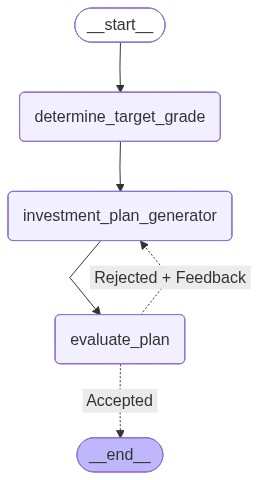

In [28]:
# initialize StateGraph with the given State schema
optimizer_builder = StateGraph(State)

# add the setup, generator, and evaluator nodes
optimizer_builder.add_node("determine_target_grade", determine_target_grade)
optimizer_builder.add_node("investment_plan_generator", investment_plan_generator)
optimizer_builder.add_node("evaluate_plan", evaluate_plan)

# define the flow with edges
optimizer_builder.add_edge(START, "determine_target_grade")
optimizer_builder.add_edge("determine_target_grade", "investment_plan_generator")
optimizer_builder.add_edge("investment_plan_generator", "evaluate_plan")
# add conditional edge for reflection
optimizer_builder.add_conditional_edges(
    "evaluate_plan",
    lambda state: route_investment(state), # we could also pass just route_investment instead of lambda function
    {
        "Accepted": END,
        "Rejected + Feedback": "investment_plan_generator",
    },
)

# compile the workflow
optimizer_workflow = optimizer_builder.compile()
# display the graph
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

In [30]:
# invoke the workflow with an example investor profile
state = optimizer_workflow.invoke({
    "investor_profile": (
        "Age: 29\n"
        "Salary: $110,000\n"
        "Assets: $40,000\n"
        "Goal: Achieve financial independence by age 45\n"
        "Risk tolerance: High"
    )
})

=== ROUTING  ===
Current grade: 'high risk'
Target risk profile: 'aggressive'
Match: False
Number of trials: 1
→ Routing to: Rejected + Feedback
=== ROUTING  ===
Current grade: 'moderate'
Target risk profile: 'aggressive'
Match: False
Number of trials: 2
→ Routing to: Rejected + Feedback
=== ROUTING  ===
Current grade: 'aggressive'
Target risk profile: 'aggressive'
Match: True
Number of trials: 3
→ Routing to: Accepted


In [31]:
def pretty_print_final_state(state: dict):
    print("🎯 Final Investment Plan Summary\n" + "="*40)
    print(f"\n📌 Investor Profile:\n{state['investor_profile']}")
    
    print("\n📈 Target Risk Grade:", state['target_grade'])
    print("📊 Final Assigned Grade:", state['grade'])
    print("🔁 Iterations Taken:", state['n'])

    print("\n📝 Evaluator Feedback:\n" + "-"*30)
    print(state['feedback'])

    print("\n📃 Final Investment Plan:\n" + "-"*30)
    print(state['investment_plan'])

pretty_print_final_state(state)

🎯 Final Investment Plan Summary

📌 Investor Profile:
Age: 29
Salary: $110,000
Assets: $40,000
Goal: Achieve financial independence by age 45
Risk tolerance: High

📈 Target Risk Grade: aggressive
📊 Final Assigned Grade: aggressive
🔁 Iterations Taken: 3

📝 Evaluator Feedback:
------------------------------
The proposed investment strategy involves a significant allocation to growth equities and commodities, which introduces higher volatility and risk. While there is an emphasis on diversification and defensive assets, the overall target return of 15% indicates a pursuit of high growth that aligns with aggressive risk tolerance. The inclusion of TIPS and high-quality bonds offers some stability, but the strategy still leans towards speculative investments, especially in high-growth sectors. Therefore, it is classified as aggressive.

📃 Final Investment Plan:
------------------------------
Based on your profile, feedback, and the need to target a 15% return while addressing the concerns ra